In [126]:
from sklearn.feature_extraction import FeatureHasher
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures


In [127]:
data=pd.read_csv('data2.csv')


In [128]:
hasher = FeatureHasher(n_features=10, input_type="string")

hashed = hasher.transform(
    data2["Destination_City"].apply(lambda x: [x])
)

hashed_df = pd.DataFrame(
    hashed.toarray(),
    columns=[f"dest_city_hash_{i}" for i in range(10)]
)

hashed_df.head()

,dest_city_hash_0,dest_city_hash_1,dest_city_hash_2,dest_city_hash_3,dest_city_hash_4,dest_city_hash_5,dest_city_hash_6,dest_city_hash_7,dest_city_hash_8,dest_city_hash_9
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [129]:
data3 = pd.concat([data2, hashed_df], axis=1)
data3.head()

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,...,dest_city_hash_0,dest_city_hash_1,dest_city_hash_2,dest_city_hash_3,dest_city_hash_4,dest_city_hash_5,dest_city_hash_6,dest_city_hash_7,dest_city_hash_8,dest_city_hash_9
0,D,NaN,4,2,311.610821,6,low,F,3,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,F,Ship,2,2,49.650596,3,medium,M,7,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,C,Road,6,2,259.168778,3,low,M,7,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,F,NaN,4,3,244.611753,3,medium,F,10,NaN,...,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0
4,F,Road,4,1,268.205824,3,medium,M,9,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [130]:
data2=pd.read_csv('data2.csv')

In [131]:

X = data2[["Discount_offered", "Cost_of_the_Product"]]
poly = PolynomialFeatures(degree=2, include_bias=False)
X_p = poly.fit_transform(X)
feature_names = poly.get_feature_names_out(["Discount_offered", "Cost_of_the_Product"])
X_poly = pd.DataFrame(X_p, columns=feature_names)
X_poly.head()

,Discount_offered,Cost_of_the_Product,Discount_offered^2,Discount_offered Cost_of_the_Product,Cost_of_the_Product^2
0,3.0,311.610821,9.0,934.832464,97101.304028
1,7.0,49.650596,49.0,347.554169,2465.181643
2,7.0,259.168778,49.0,1814.181446,67168.455505
3,10.0,244.611753,100.0,2446.117534,59834.909920
4,9.0,268.205824,81.0,2413.852415,71934.363989


In [132]:
data4 = pd.concat([data3,X_poly ], axis=1)
data4

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,...,dest_city_hash_5,dest_city_hash_6,dest_city_hash_7,dest_city_hash_8,dest_city_hash_9,Discount_offered,Cost_of_the_Product,Discount_offered^2,Discount_offered Cost_of_the_Product,Cost_of_the_Product^2
0,D,NaN,4,2,311.610821,6,low,F,3,NaN,...,0.0,0.0,0.0,1.0,0.0,3.0,311.610821,9.0,934.832464,97101.304028
1,F,Ship,2,2,49.650596,3,medium,M,7,NaN,...,0.0,0.0,0.0,1.0,0.0,7.0,49.650596,49.0,347.554169,2465.181643
2,C,Road,6,2,259.168778,3,low,M,7,NaN,...,0.0,0.0,0.0,0.0,1.0,7.0,259.168778,49.0,1814.181446,67168.455505
3,F,NaN,4,3,244.611753,3,medium,F,10,NaN,...,0.0,0.0,0.0,0.0,0.0,10.0,244.611753,100.0,2446.117534,59834.909920
4,F,Road,4,1,268.205824,3,medium,M,9,NaN,...,0.0,0.0,0.0,0.0,1.0,9.0,268.205824,81.0,2413.852415,71934.363989
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,B,Road,5,1,328.756075,3,medium,M,12,574.204647,...,0.0,0.0,0.0,0.0,-1.0,12.0,328.756075,144.0,3945.072901,108080.556923
996,A,Ship,6,5,61.328146,8,low,M,8,2161.851553,...,0.0,0.0,0.0,0.0,0.0,8.0,61.328146,64.0,490.625166,3761.141466
997,A,Road,4,4,92.280223,6,high,M,4,2334.039534,...,0.0,0.0,-1.0,0.0,0.0,4.0,92.280223,16.0,369.120892,8515.639567
998,D,Flight,3,5,193.313501,6,medium,F,6,4266.537931,...,0.0,0.0,0.0,0.0,0.0,6.0,193.313501,36.0,1159.881005,37370.109632


Hashing for every feature


In [133]:
hasher = FeatureHasher(n_features=10, input_type="string")

hashed = hasher.transform(
    data2["Warehouse_block"].apply(lambda x: [x])
)

hashed_df = pd.DataFrame(
    hashed.toarray(),
    columns=[f"Warehouse_block_{i}" for i in range(10)]
)

hashed_df.head()

,Warehouse_block_0,Warehouse_block_1,Warehouse_block_2,Warehouse_block_3,Warehouse_block_4,Warehouse_block_5,Warehouse_block_6,Warehouse_block_7,Warehouse_block_8,Warehouse_block_9
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0
2,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0


In [134]:
hasher = FeatureHasher(n_features=10, input_type="string")

hashed = hasher.transform(
    data2["Product_importance"].apply(lambda x: [x])
)

hashed_df = pd.DataFrame(
    hashed.toarray(),
    columns=[f"Product_importance_{i}" for i in range(10)]
)

hashed_df.head()

,Product_importance_0,Product_importance_1,Product_importance_2,Product_importance_3,Product_importance_4,Product_importance_5,Product_importance_6,Product_importance_7,Product_importance_8,Product_importance_9
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [135]:
hasher = FeatureHasher(n_features=10, input_type="string")

hashed = hasher.transform(
    data2["Gender"].apply(lambda x: [x])
)

hashed_df = pd.DataFrame(
    hashed.toarray(),
    columns=[f"Gender_{i}" for i in range(10)]
)

hashed_df.head()

,Gender_0,Gender_1,Gender_2,Gender_3,Gender_4,Gender_5,Gender_6,Gender_7,Gender_8,Gender_9
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


K-Means

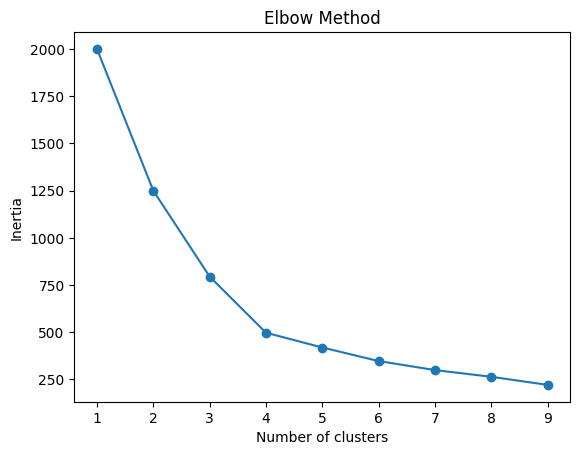

In [136]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler,LabelEncoder

le=LabelEncoder()
data['Cost_of_the_Product']=le.fit_transform(data['Cost_of_the_Product'])
data['Weight_in_gms']=le.fit_transform(data['Weight_in_gms'])
scaler = StandardScaler()
scaled_features = scaler.fit_transform(data[['Weight_in_gms', 'Cost_of_the_Product']])

inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [143]:

kmeans = KMeans(n_clusters=4, random_state=42)
data['Cluster'] = kmeans.fit_predict(scaled_features)

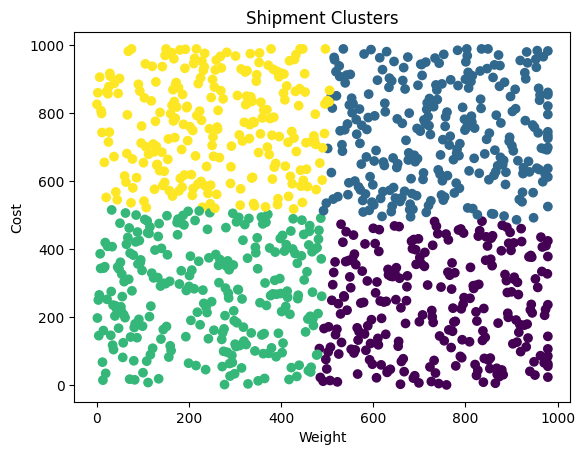

In [144]:
plt.scatter(data['Weight_in_gms'], data['Cost_of_the_Product'], c=data['Cluster'], cmap='viridis')
plt.xlabel('Weight')
plt.ylabel('Cost')
plt.title('Shipment Clusters')
plt.show()